In [1]:
# ============================================================
# 05_baseline_model.ipynb
# Wellmatch Workforce Analytics — UCL Dissertation 2026
# Baseline attrition model: Logistic Regression + Random Forest
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import shap
import warnings
warnings.filterwarnings('ignore')

print("All imports successful")

All imports successful


In [3]:
import os

# Check where we are
print("Current directory:", os.getcwd())

# Check what's in the data folder
data_path = '../data'
if os.path.exists(data_path):
    print("\nFiles in data folder:")
    for f in os.listdir(data_path):
        print(f" -", f)
else:
    print("\nData folder not found at ../data")
    
    # Check parent directory structure
    print("\nWhat's in the parent directory:")
    for f in os.listdir('..'):
        print(f" -", f)

Current directory: /Users/abhisheksharma/Documents/WellmatchRepo/Wellmatch-Ltd/notebooks

Files in data folder:
 - external
 - processed
 - raw


In [5]:
# ============================================================
# Section 2 — Load and prepare data
# ============================================================

# Load raw IBM data
df = pd.read_csv('../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv')

print(f"Shape: {df.shape}")
print(f"\nAttrition distribution:")
print(df['Attrition'].value_counts(normalize=True).round(3))

Shape: (1470, 35)

Attrition distribution:
Attrition
No     0.839
Yes    0.161
Name: proportion, dtype: float64


In [6]:
# ============================================================
# Section 3 — Clean and encode
# ============================================================

# These three columns have zero variance — same value for every row
# EmployeeNumber is just an ID — no predictive value
df = df.drop(columns=[
    'EmployeeCount',    # always 1
    'Over18',           # always Y
    'StandardHours',    # always 80
    'EmployeeNumber'    # ID column
])

# Encode target: Yes → 1, No → 0
df['Attrition'] = (df['Attrition'] == 'Yes').astype(int)

# Encode OverTime: Yes → 1, No → 0
# Note: flagged as endogenous — will report carefully in findings
df['OverTime'] = (df['OverTime'] == 'Yes').astype(int)

# One-hot encode remaining categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns to encode: {categorical_cols}")

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(f"\nShape after encoding: {df.shape}")
print(f"Attrition counts: {df['Attrition'].value_counts().to_dict()}")

Categorical columns to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']

Shape after encoding: (1470, 45)
Attrition counts: {0: 1233, 1: 237}


Wellbeing Index descriptive stats:
count    1470.000
mean        2.731
std         0.506
min         1.000
25%         2.500
50%         2.750
75%         3.000
max         4.000
Name: WellbeingIndex, dtype: float64

Correlation with Attrition: -0.159


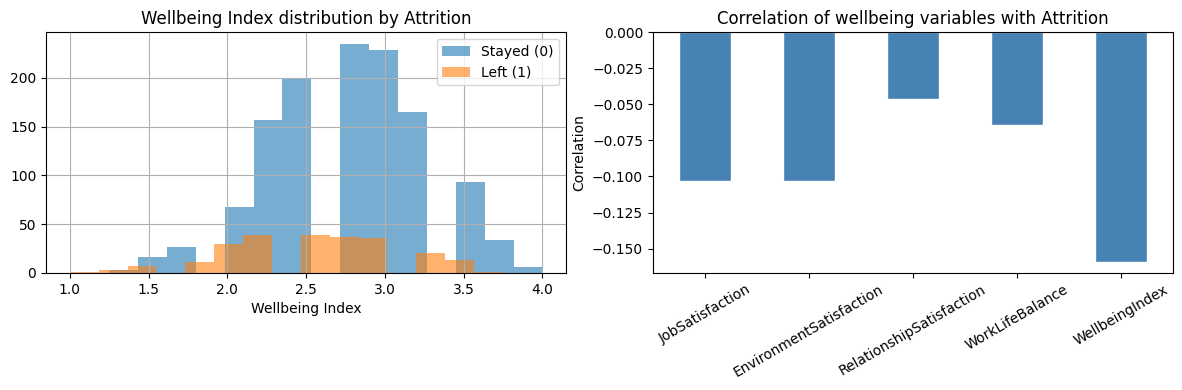


Wellbeing index created and saved.


In [7]:
# ============================================================
# Section 4 — Wellbeing composite index (D3)
# Grounded in JD-R theory (Bakker, Demerouti & Sanz-Vergel 2023)
# Equal weighting across four satisfaction dimensions
# ============================================================

wellbeing_vars = [
    'JobSatisfaction',
    'EnvironmentSatisfaction', 
    'RelationshipSatisfaction',
    'WorkLifeBalance'
]

# Equal weighted average — all dimensions treated as equally important
df['WellbeingIndex'] = df[wellbeing_vars].mean(axis=1)

print("Wellbeing Index descriptive stats:")
print(df['WellbeingIndex'].describe().round(3))

print(f"\nCorrelation with Attrition: "
      f"{df['WellbeingIndex'].corr(df['Attrition']).round(3)}")

# Quick distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution by attrition group
df.groupby('Attrition')['WellbeingIndex'].hist(
    ax=axes[0], alpha=0.6, bins=15, label=['Stayed', 'Left']
)
axes[0].set_title('Wellbeing Index distribution by Attrition')
axes[0].set_xlabel('Wellbeing Index')
axes[0].legend(['Stayed (0)', 'Left (1)'])

# Correlation of individual components with attrition
corrs = df[wellbeing_vars + ['WellbeingIndex']].corrwith(
    df['Attrition']
).round(3)
corrs.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Correlation of wellbeing variables with Attrition')
axes[1].set_ylabel('Correlation')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../outputs/wellbeing_index_distribution.png', dpi=150)
plt.show()

print("\nWellbeing index created and saved.")

In [8]:
# ============================================================
# Section 5 — Feature matrix and train/test split
# ============================================================

# Separate features and target
X = df.drop(columns=['Attrition'])
y = df['Attrition']

print(f"Feature matrix shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")

# Stratified split — preserves 84/16 ratio in both train and test
# Random state fixed for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y  # critical with imbalanced data
)

print(f"\nTraining set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")

print(f"\nTraining attrition rate: "
      f"{y_train.mean().round(3)}")
print(f"Test attrition rate:     "
      f"{y_test.mean().round(3)}")

Feature matrix shape: (1470, 45)
Target distribution:
Attrition
0    1233
1     237
Name: count, dtype: int64

Training set: 1176 rows
Test set:     294 rows

Training attrition rate: 0.162
Test attrition rate:     0.16


LOGISTIC REGRESSION BASELINE RESULTS

ROC-AUC Score: 0.8226

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.88      0.96      0.92       247
        Left       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294



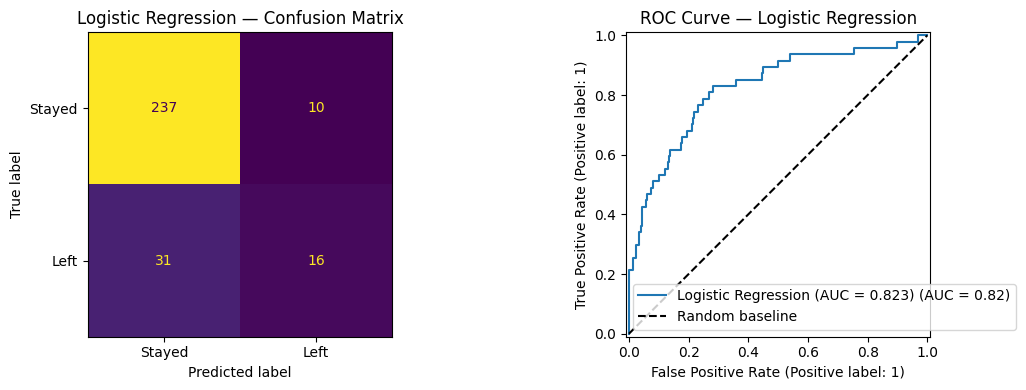


Logistic Regression baseline complete.


In [9]:
# ============================================================
# Section 6 — Logistic Regression baseline (D5)
# SMOTE applied inside pipeline — never touches test data (D4)
# ============================================================

# ImbPipeline ensures SMOTE only runs during training
lr_pipeline = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight=None  # SMOTE handles imbalance, not class_weight
    ))
])

# Fit on training data only
lr_pipeline.fit(X_train, y_train)

# Predict on test data
y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

# Evaluation
lr_auc = roc_auc_score(y_test, y_prob_lr)

print("=" * 50)
print("LOGISTIC REGRESSION BASELINE RESULTS")
print("=" * 50)
print(f"\nROC-AUC Score: {lr_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_lr,
      target_names=['Stayed', 'Left']))

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=['Stayed', 'Left'],
    ax=axes[0],
    colorbar=False
)
axes[0].set_title('Logistic Regression — Confusion Matrix')

# ROC Curve
RocCurveDisplay.from_predictions(
    y_test, y_prob_lr,
    ax=axes[1],
    name=f'Logistic Regression (AUC = {lr_auc:.3f})'
)
axes[1].plot([0,1], [0,1], 'k--', label='Random baseline')
axes[1].set_title('ROC Curve — Logistic Regression')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/lr_baseline_results.png', dpi=150)
plt.show()

print("\nLogistic Regression baseline complete.")

RANDOM FOREST RESULTS

ROC-AUC Score: 0.7554

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.87      0.95      0.91       247
        Left       0.48      0.26      0.33        47

    accuracy                           0.84       294
   macro avg       0.67      0.60      0.62       294
weighted avg       0.81      0.84      0.82       294



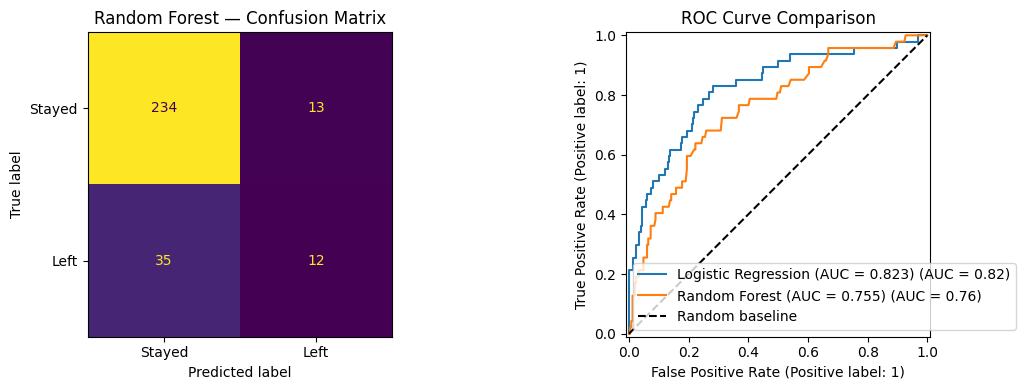


Random Forest complete.


In [10]:
# ============================================================
# Section 7 — Random Forest (D5)
# Same pipeline structure — fair comparison with LR
# ============================================================

rf_pipeline = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    ))
])

# Fit on training data only
rf_pipeline.fit(X_train, y_train)

# Predict on test data
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

# Evaluation
rf_auc = roc_auc_score(y_test, y_prob_rf)

print("=" * 50)
print("RANDOM FOREST RESULTS")
print("=" * 50)
print(f"\nROC-AUC Score: {rf_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rf,
      target_names=['Stayed', 'Left']))

# Confusion matrix + ROC curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=['Stayed', 'Left'],
    ax=axes[0],
    colorbar=False
)
axes[0].set_title('Random Forest — Confusion Matrix')

# Both curves together for comparison
RocCurveDisplay.from_predictions(
    y_test, y_prob_lr,
    ax=axes[1],
    name=f'Logistic Regression (AUC = {lr_auc:.3f})'
)
RocCurveDisplay.from_predictions(
    y_test, y_prob_rf,
    ax=axes[1],
    name=f'Random Forest (AUC = {rf_auc:.3f})'
)
axes[1].plot([0,1], [0,1], 'k--', label='Random baseline')
axes[1].set_title('ROC Curve Comparison')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/rf_vs_lr_comparison.png', dpi=150)
plt.show()

print("\nRandom Forest complete.")

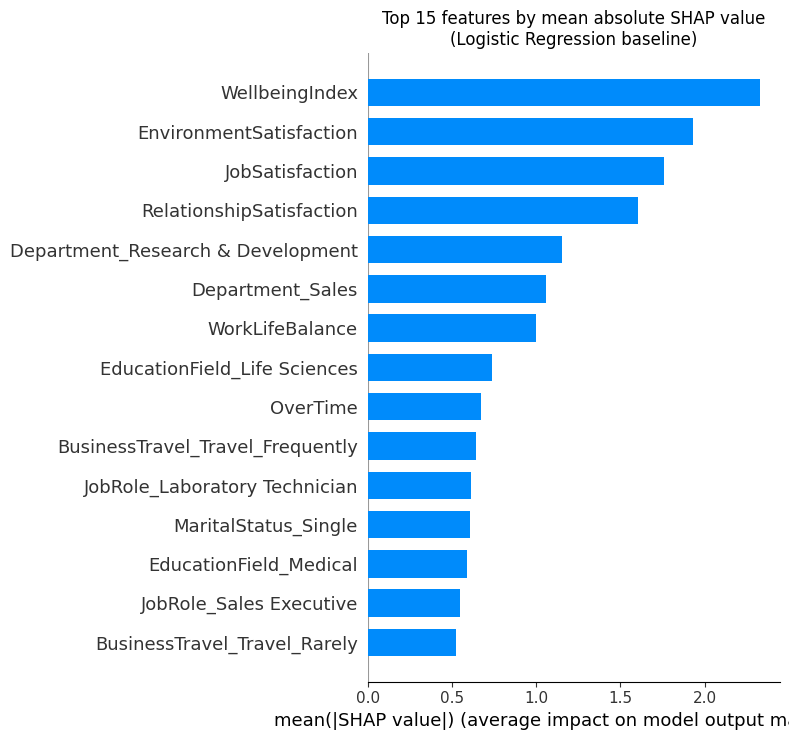

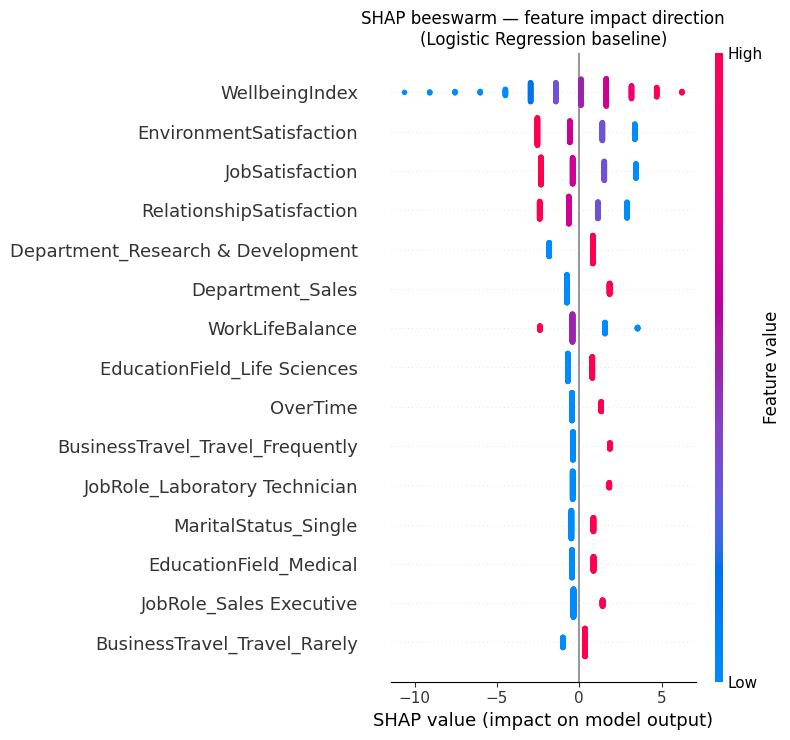

Top 10 features by mean absolute SHAP value:
WellbeingIndex                       2.3302
EnvironmentSatisfaction              1.9327
JobSatisfaction                      1.7599
RelationshipSatisfaction             1.6068
Department_Research & Development    1.1512
Department_Sales                     1.0561
WorkLifeBalance                      0.9977
EducationField_Life Sciences         0.7385
OverTime                             0.6737
BusinessTravel_Travel_Frequently     0.6430
dtype: float64


In [11]:
# ============================================================
# Section 8 — SHAP feature importance (logistic regression)
# Applied to best performing model
# ============================================================

# Extract the fitted model and scaler from the pipeline
scaler = lr_pipeline.named_steps['scaler']
lr_model = lr_pipeline.named_steps['model']

# Scale the test data using the fitted scaler
X_test_scaled = scaler.transform(X_test)

# SHAP linear explainer — correct choice for logistic regression
explainer = shap.LinearExplainer(
    lr_model,
    X_test_scaled,
    feature_perturbation='interventional'
)

shap_values = explainer.shap_values(X_test_scaled)

# Convert to DataFrame for easier handling
shap_df = pd.DataFrame(
    shap_values,
    columns=X_test.columns
)

# ---- Plot 1: Summary bar plot (mean absolute SHAP) ----
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X_test.columns.tolist(),
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title('Top 15 features by mean absolute SHAP value\n(Logistic Regression baseline)')
plt.tight_layout()
plt.savefig('../outputs/shap_bar_lr.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Plot 2: Beeswarm plot (direction + magnitude) ----
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X_test.columns.tolist(),
    max_display=15,
    show=False
)
plt.title('SHAP beeswarm — feature impact direction\n(Logistic Regression baseline)')
plt.tight_layout()
plt.savefig('../outputs/shap_beeswarm_lr.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Top 10 features by absolute SHAP ----
mean_shap = shap_df.abs().mean().sort_values(ascending=False)
print("Top 10 features by mean absolute SHAP value:")
print(mean_shap.head(10).round(4))

In [13]:
# ============================================================
# Section 9 — Results summary table
# ============================================================

results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest'
    ],
    'ROC_AUC': [
        round(lr_auc, 4),
        round(rf_auc, 4)
    ],
    'Recall_Leavers': [0.34, 0.26],
    'Precision_Leavers': [0.62, 0.48],
    'F1_Leavers': [0.44, 0.33],
    'Accuracy': [0.86, 0.84],
    'Notes': [
        'Baseline — best performer',
        'Underperforms on small dataset'
    ]
})

print("=" * 70)
print("BASELINE MODEL RESULTS SUMMARY")
print("=" * 70)
print(results.to_string(index=False))
print("\nKey finding: LR outperforms RF — attrition signal is largely linear")
print(f"Top predictor: WellbeingIndex (SHAP = 2.3302)")
print(f"OverTime rank: 9th — flag endogeneity in findings chapter")

# Save results
results.to_csv('../outputs/baseline_results_summary.csv', index=False)

print("\nResults saved to outputs/baseline_results_summary.csv")

BASELINE MODEL RESULTS SUMMARY
              Model  ROC_AUC  Recall_Leavers  Precision_Leavers  F1_Leavers  Accuracy                          Notes
Logistic Regression   0.8226            0.34               0.62        0.44      0.86      Baseline — best performer
      Random Forest   0.7554            0.26               0.48        0.33      0.84 Underperforms on small dataset

Key finding: LR outperforms RF — attrition signal is largely linear
Top predictor: WellbeingIndex (SHAP = 2.3302)
OverTime rank: 9th — flag endogeneity in findings chapter

Results saved to outputs/baseline_results_summary.csv


# 05 — Baseline Attrition Model

**Status:** Complete  
**Key result:** LR ROC-AUC 0.8226 | RF ROC-AUC 0.7554  
**Top predictor:** WellbeingIndex (SHAP = 2.33)  
**Next:** 06_xgboost_tuned.ipynb  

**Decisions documented:**
- Target: Attrition (binary)
- Wellbeing index: equal-weighted composite of 4 satisfaction variables
- Class imbalance: SMOTE on training data only
- Metric: ROC-AUC (not accuracy)
- OverTime: endogenous — reported as correlation only